## Customer Churn Prediction

## Introduction and Problem Statement

The objective of this task is to predict whether a bank customer will leave the bank (churn) or not. This is a binary classification problem where the target variable 'Exited' indicates whether a customer has churned.

The goal is to analyze customer data and build a model that helps the bank identify customers who are likely to leave.

## Dataset Description

The dataset contains customer information such as credit score, geography, gender, age, balance, and salary.

The target variable is 'Exited':
- 1 = Customer left the bank
- 0 = Customer stayed

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [3]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Dataset Understanding**

df.shape
df.columns
df.info()

**Data Cleaning (Check missing values)**

In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

**Drop unnecessary columns**

In [6]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploratory Data Analysis (EDA)

**Age Distribution**

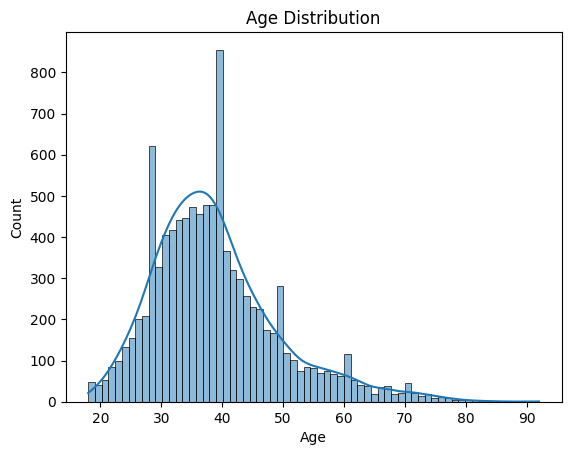

In [8]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

**Balance Distribution**

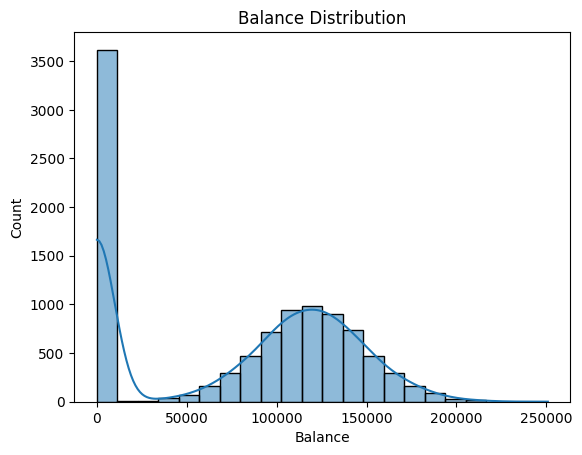

In [9]:
sns.histplot(df['Balance'], kde=True)
plt.title("Balance Distribution")
plt.show()

**Geography vs Churn**

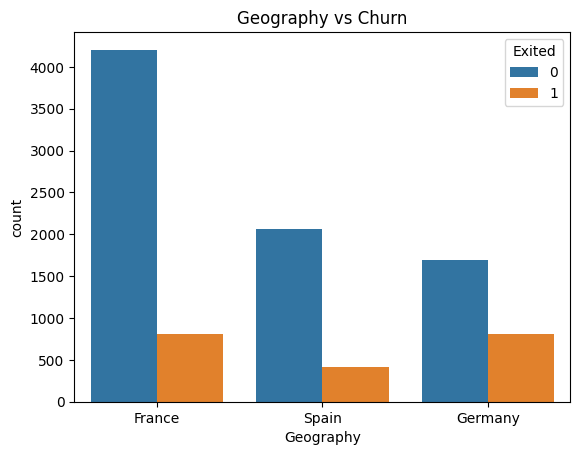

In [10]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Geography vs Churn")
plt.show()

**Gender vs Churn**

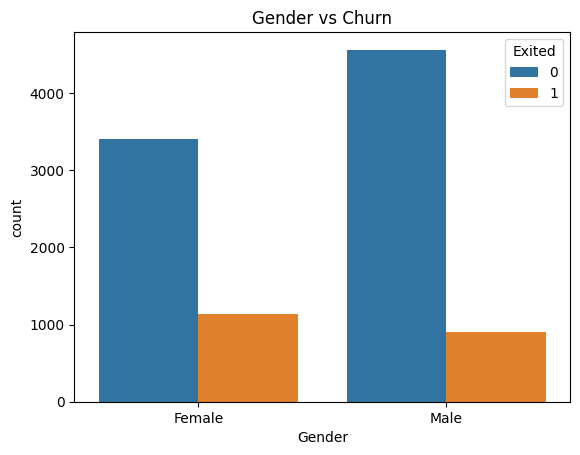

In [11]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Gender vs Churn")
plt.show()

## Encode Categorical Features

**One-Hot Encoding (Geography)**

In [12]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

**Label Encoding (Gender)**

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

## Define Features & Target

In [14]:
X = df.drop('Exited', axis=1)
y = df['Exited']

## Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Model (Random Forest)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predictions

In [17]:
y_pred = model.predict(X_test)

## Evaluation

**Accuracy**

In [18]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8665


**Confusion Matrix**

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1547   60]
 [ 207  186]]


**Heatmap**

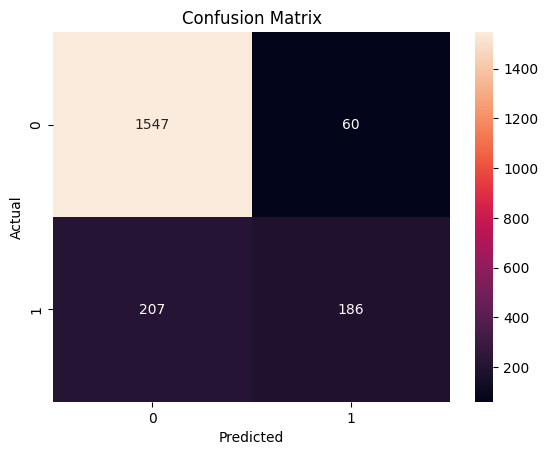

In [20]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

In [21]:
importances = model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
2,Age,0.237442
8,EstimatedSalary,0.146367
0,CreditScore,0.141272
4,Balance,0.139568
5,NumOfProducts,0.136866
3,Tenure,0.080094
7,IsActiveMember,0.039653
9,Geography_Germany,0.026132
1,Gender,0.019259
6,HasCrCard,0.019075


**Visualize Feature Importance**

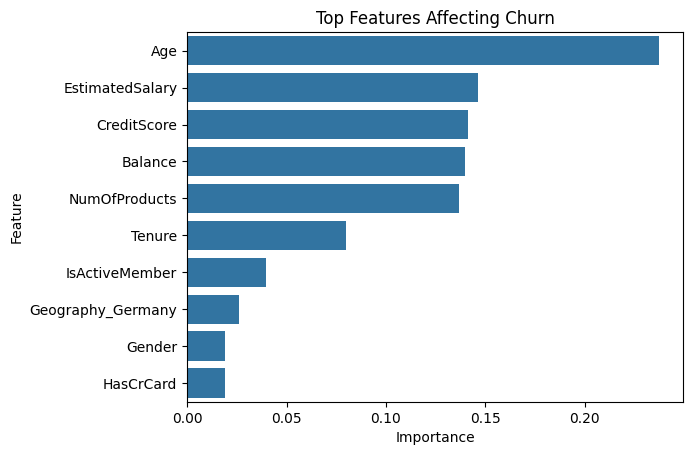

In [22]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)
plt.title("Top Features Affecting Churn")
plt.show()

## Custom Input Prediction

In [25]:
## Create Sample Customer
new_customer = X.iloc[0:1].copy()

## Modify Values
new_customer['CreditScore'] = 650
new_customer['Age'] = 40
new_customer['Balance'] = 60000
new_customer['EstimatedSalary'] = 50000
new_customer['Tenure'] = 5
new_customer['NumOfProducts'] = 2
new_customer['IsActiveMember'] = 1
new_customer['HasCrCard'] = 1

## Handle Encoded Columns
# Gender: 1 = Male, 0 = Female
new_customer['Gender'] = 1  

# Geography (One-Hot Encoding)
new_customer['Geography_Germany'] = 0
new_customer['Geography_Spain'] = 1   # Spain customer

## Make Prediction
prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is likely to STAY")

Customer is likely to STAY


## Conclusion

In this task, we analyzed customer data to predict churn. The dataset was cleaned and categorical variables were encoded properly.

A Random Forest model was trained and evaluated using accuracy and confusion matrix. Feature importance analysis showed that variables such as age, balance, and geography significantly influence customer churn.

This model can help banks take proactive steps to retain customers.